# Imports

In [1]:
# Import necessary libraries
from pyhgf.model import Network
from scipy.stats import norm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from voting import generate_observations, generate_candidates, individual_vote, init_preferences,calculate_kl_divergence
import colorsys
# Import JAX and related modules
import jax.numpy as jnp
from jax import random, vmap
from jax.tree_util import Partial
import time
import numpy as np
from scipy.stats import norm, halfnorm

# Style

In [2]:
# --- Global style for plots ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Parameters

In [3]:
# --- Simulation parameters ---
n_preferences = 2             # Number of preference dimensions
voting_system = "basic"       # Options: "basic", "basic (ToM)", "ranked", "quadratic"
n_candidates = 2              # Number of candidates per round
n_simulations = 500           # Number of simulations to run
n_agents = 50 * n_simulations # Total number of agents
mask = np.ones(n_candidates)  # Mask for second round candidates (not used here)
input_data = generate_observations(n_nodes=n_preferences, n_steps=500, scenario=1) # Generate observations

# --- Agent parameters ---
tonic_volatilities = np.random.normal(-3.0, 1.0, n_agents)
prefs = init_preferences(n_agents, n_preferences)
all_mus = prefs["mean"]
all_pis = prefs["precision"]
all_sigmas = 1 / np.sqrt(all_pis)

# --- Candidate distributions ---
#candidate_list = generate_candidates(n_candidates=n_candidates, n_preferences=n_preferences)

# Optional: manual candidate definitions
manual_means_candidates = [[3.0, 1.0], [2.0, 4.0]]
manual_precisions_candidates = [[1, 0.8], [0.8, 1]]
candidate_list = [(np.array(m), 1/np.sqrt(np.array(p))) 
                   for m, p in zip(manual_means_candidates, manual_precisions_candidates)]

# Plot 1 - Preference Distribution

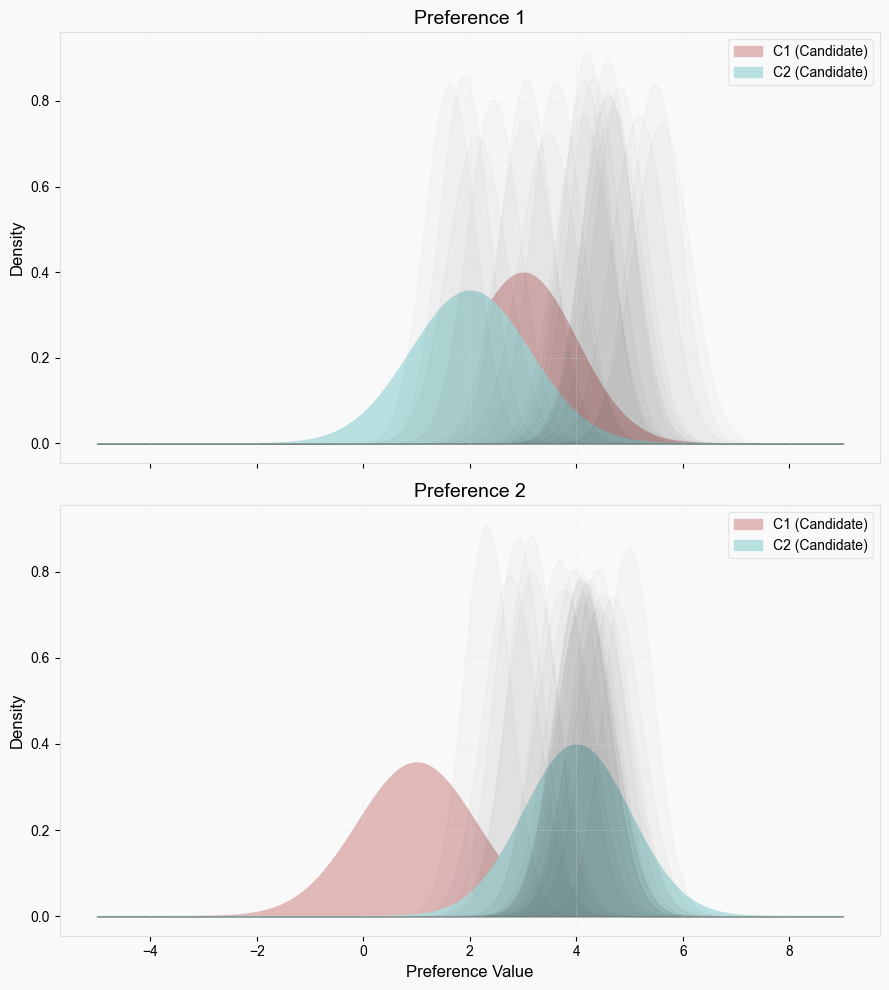

In [4]:
# --- Prepare DataFrame for PDFs ---
x_min, x_max = -5, 9
x_vals = np.linspace(x_min, x_max, 300)
rows = []

# --- Candidates ---
for i, (mus, sigmas) in enumerate(candidate_list):
    for pref in range(n_preferences):
        pdf = norm.pdf(x_vals, loc=mus[pref], scale=sigmas[pref])
        rows.extend([{
            "group": "Candidate",
            "id": f"C{i+1}",
            "preference": f"Preference {pref+1}",
            "x": x,
            "pdf": y
        } for x, y in zip(x_vals, pdf)])

# --- Agents ---
for i in range(n_agents):
    mus = all_mus[i]
    sigmas = all_sigmas[i]
    for pref in range(n_preferences):
        pdf = norm.pdf(x_vals, loc=mus[pref], scale=sigmas[pref])
        rows.extend([{
            "group": "Agent",
            "id": f"A{i+1}",
            "preference": f"Preference {pref+1}",
            "x": x,
            "pdf": y
        } for x, y in zip(x_vals, pdf)])

# --- Final DataFrame ---
df = pd.DataFrame(rows)

# --- Pastel colors for candidates ---
candidate_ids = [c for c in df["id"].unique() if c.startswith("C")]
n_candidates = len(candidate_ids)
colors = [colorsys.hls_to_rgb(i / n_candidates, 0.8, 0.4) for i in range(n_candidates)]

# --- Plot ---
preferences = df["preference"].unique()
agents_to_plot = [a for a in df["id"].unique() if a.startswith("A")][:20]  # first 20 agents

fig, axes = plt.subplots(len(preferences), 1, figsize=(9, 5 * len(preferences)), sharex=True, facecolor="#f9f9f9")
axes = [axes] if len(preferences) == 1 else axes

for ax, pref in zip(axes, preferences):
    ax.set_facecolor("#f9f9f9")
    sub_df = df[df["preference"] == pref]

    # Plot candidates
    for j, cand in enumerate(candidate_ids):
        cand_df = sub_df[sub_df["id"] == cand]
        ax.fill_between(cand_df["x"], cand_df["pdf"], color=colors[j], label=f"{cand} (Candidate)")

    # Plot agents
    for agent in agents_to_plot:
        agent_df = sub_df[sub_df["id"] == agent]
        ax.fill_between(agent_df["x"], agent_df["pdf"], color="black", alpha=0.02)

    ax.set_title(pref, fontsize=14)
    ax.set_ylabel("Density", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.4, color="#e0e0e0", linewidth=0.5)

    for spine in ax.spines.values():
        spine.set_edgecolor("#e0e0e0")
        spine.set_linewidth(0.8)

    ax.legend(facecolor="#f9f9f9", edgecolor="#e0e0e0")

axes[-1].set_xlabel("Preference Value", fontsize=12)
plt.tight_layout()
plt.show()

# Plots 2 - Belief evolution

- Ploter la disatisfaction as a surprise

## Scenario 1

Dissatisfaction (KL Divergence) over time:


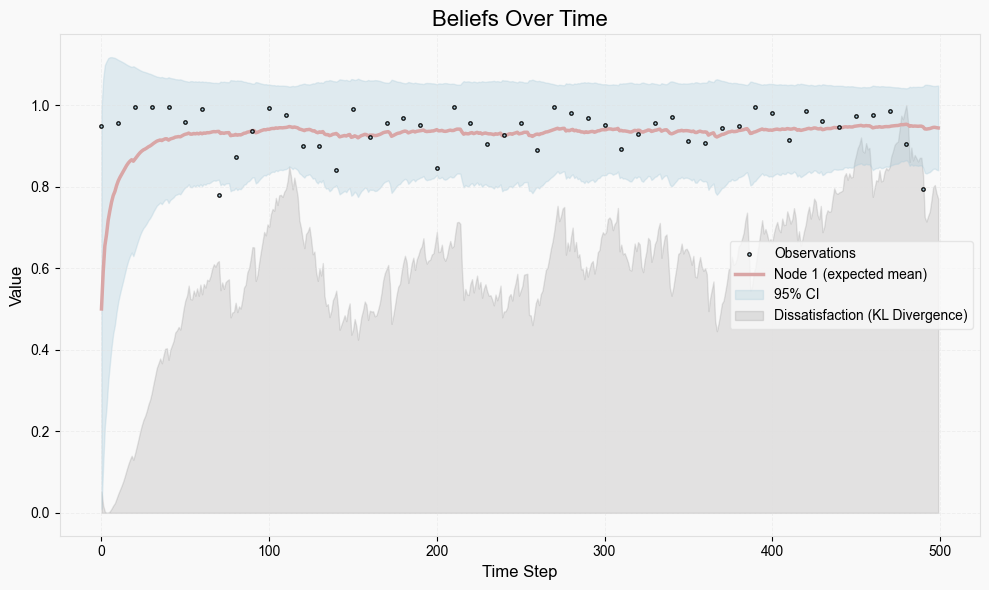

In [5]:
# --- Create agent preference network dynamically ---
network = Network()

# Add binary-state nodes
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network structure
network.plot_network()
input_data = generate_observations(n_nodes=n_preferences, n_steps=500, scenario=1, dispersion=0)

# Feed input data into the network
network.input_data(input_data)

# Setup for dissatisfaction calculation
expected_mean = network.node_trajectories[0]["expected_mean"]
expected_precision = network.node_trajectories[0]["precision"]

# Reference preferences (baseline), same at each time step
baseline_mean = np.tile(all_mus[0][0], (len(expected_mean), 1))
baseline_precision = np.tile(all_sigmas[0][0], (len(expected_mean), 1))

# Storage for dissatisfaction at each step
dissatisfaction_over_time = []

# Compute dissatisfaction at each step
for t in range(len(expected_mean)):
    dissatisfaction = calculate_kl_divergence(
        expected_mean[t],
        expected_precision[t],  # precision is converted inside KL function
        baseline_mean[t],
        baseline_precision[t]
    )
    dissatisfaction_over_time.append(dissatisfaction)

# Display dissatisfaction over time
print("Dissatisfaction (KL Divergence) over time:")
dissatisfaction_over_time

# --- Colors (pastel) ---
obs_color = colorsys.hls_to_rgb(0.55, 0.75, 0.4)  # pastel blue
mean_color = colorsys.hls_to_rgb(0.0, 0.75, 0.4)  # pastel red
diss_color = "#181515"  # very dark gray

# --- Figure ---
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#f9f9f9')
ax.set_facecolor('#f9f9f9')

# Scatter plot of observations (every 10 points)
ax.scatter(
    range(0, len(input_data[:, 0]), 10),
    input_data[::10, 0],
    label="Observations",
    color=obs_color,
    edgecolor="k",
    alpha=0.9,
    s=6,
    zorder=3
)

# Plot expected mean
mean = network.node_trajectories[0]["expected_mean"]
ax.plot(
    mean,
    label="Node 1 (expected mean)",
    color=mean_color,
    linewidth=2.5,
    zorder=2
)

# Confidence interval (95%) 
# NOTE: convert precision -> variance -> std if needed
std = network.node_trajectories[0]["expected_precision"]  
upper = mean + 1.96 * std
lower = mean - 1.96 * std

ax.fill_between(
    range(len(mean)),
    lower,
    upper,
    color=obs_color,
    alpha=0.3,
    label="95% CI",
    zorder=1
)

# Normalize dissatisfaction for visualization
diss = np.array(dissatisfaction_over_time).flatten()
diss_scaled = (diss - diss.min()) / (diss.max() - diss.min())

# Add shaded area for dissatisfaction
ax.fill_between(
    range(len(dissatisfaction_over_time)),
    0,  # Base of the shaded area is the x-axis (value 0)
    diss_scaled,
    label="Dissatisfaction (KL Divergence)",
    color=diss_color,
    alpha=0.1,
    zorder=0
)

# --- Titles & labels ---
ax.set_title("Beliefs Over Time", fontsize=16)
ax.set_xlabel("Time Step", fontsize=12)
ax.set_ylabel("Value", fontsize=12)

# --- Grid & spines ---
ax.grid(True, linestyle='--', alpha=0.4, color='#e0e0e0', linewidth=0.7)
for spine in ax.spines.values():
    spine.set_edgecolor('#e0e0e0')
    spine.set_linewidth(0.8)

# --- Legend ---
ax.legend(facecolor='#f9f9f9', edgecolor='#e0e0e0')

plt.tight_layout()
plt.show()


## Scenario 2

In [6]:
dissatisfaction_over_time

[Array([2.6415987], dtype=float32),
 Array([2.516953], dtype=float32),
 Array([2.4612029], dtype=float32),
 Array([2.4496448], dtype=float32),
 Array([2.4505334], dtype=float32),
 Array([2.4636772], dtype=float32),
 Array([2.4872756], dtype=float32),
 Array([2.515121], dtype=float32),
 Array([2.5376487], dtype=float32),
 Array([2.578882], dtype=float32),
 Array([2.62044], dtype=float32),
 Array([2.6574583], dtype=float32),
 Array([2.694561], dtype=float32),
 Array([2.7353601], dtype=float32),
 Array([2.7842004], dtype=float32),
 Array([2.8373728], dtype=float32),
 Array([2.8869605], dtype=float32),
 Array([2.9294395], dtype=float32),
 Array([2.964246], dtype=float32),
 Array([2.928164], dtype=float32),
 Array([2.983775], dtype=float32),
 Array([3.0470803], dtype=float32),
 Array([3.1108644], dtype=float32),
 Array([3.177826], dtype=float32),
 Array([3.236267], dtype=float32),
 Array([3.2866657], dtype=float32),
 Array([3.321697], dtype=float32),
 Array([3.368397], dtype=float32),
 Arra

Dissatisfaction (KL Divergence) over time:


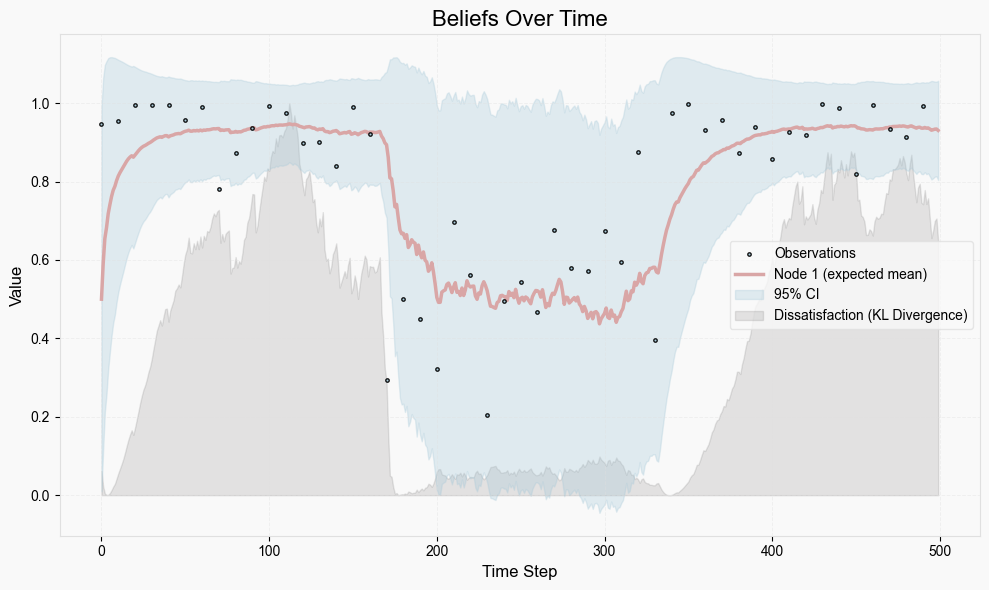

In [7]:
# --- Create agent preference network dynamically ---
network = Network()

# Add binary-state nodes
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network structure
network.plot_network()
input_data = generate_observations(n_nodes=n_preferences, n_steps=500, scenario=2, dispersion=0)

# Feed input data into the network
network.input_data(input_data)

# Setup for dissatisfaction calculation
expected_mean = network.node_trajectories[0]["expected_mean"]
expected_precision = network.node_trajectories[0]["precision"]

# Reference preferences (baseline), same at each time step
baseline_mean = np.tile(all_mus[0][0], (len(expected_mean), 1))
baseline_precision = np.tile(all_sigmas[0][0], (len(expected_mean), 1))

# Storage for dissatisfaction at each step
dissatisfaction_over_time = []

# Compute dissatisfaction at each step
for t in range(len(expected_mean)):
    dissatisfaction = calculate_kl_divergence(
        expected_mean[t],
        expected_precision[t],  # precision is converted inside KL function
        baseline_mean[t],
        baseline_precision[t]
    )
    dissatisfaction_over_time.append(dissatisfaction)

# Display dissatisfaction over time
print("Dissatisfaction (KL Divergence) over time:")
dissatisfaction_over_time

# --- Colors (pastel) ---
obs_color = colorsys.hls_to_rgb(0.55, 0.75, 0.4)  # pastel blue
mean_color = colorsys.hls_to_rgb(0.0, 0.75, 0.4)  # pastel red
diss_color = "#181515"  # very dark gray

# --- Figure ---
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#f9f9f9')
ax.set_facecolor('#f9f9f9')

# Scatter plot of observations (every 10 points)
ax.scatter(
    range(0, len(input_data[:, 0]), 10),
    input_data[::10, 0],
    label="Observations",
    color=obs_color,
    edgecolor="k",
    alpha=0.9,
    s=6,
    zorder=3
)

# Plot expected mean
mean = network.node_trajectories[0]["expected_mean"]
ax.plot(
    mean,
    label="Node 1 (expected mean)",
    color=mean_color,
    linewidth=2.5,
    zorder=2
)

# Confidence interval (95%) 
std = network.node_trajectories[0]["expected_precision"]  
upper = mean + 1.96 * std
lower = mean - 1.96 * std

ax.fill_between(
    range(len(mean)),
    lower,
    upper,
    color=obs_color,
    alpha=0.3,
    label="95% CI",
    zorder=1
)

# Normalize dissatisfaction for visualization
diss = np.array(dissatisfaction_over_time).flatten()
diss_scaled = (diss - diss.min()) / (diss.max() - diss.min())

# Add shaded area for dissatisfaction
ax.fill_between(
    range(len(dissatisfaction_over_time)),
    0,  # Base of the shaded area is the x-axis (value 0)
    diss_scaled,
    label="Dissatisfaction (KL Divergence)",
    color=diss_color,
    alpha=0.1,
    zorder=0
)

# --- Titles & labels ---
ax.set_title("Beliefs Over Time", fontsize=16)
ax.set_xlabel("Time Step", fontsize=12)
ax.set_ylabel("Value", fontsize=12)

# --- Grid & spines ---
ax.grid(True, linestyle='--', alpha=0.4, color='#e0e0e0', linewidth=0.7)
for spine in ax.spines.values():
    spine.set_edgecolor('#e0e0e0')
    spine.set_linewidth(0.8)

# --- Legend ---
ax.legend(facecolor='#f9f9f9', edgecolor='#e0e0e0')

plt.tight_layout()
plt.show()


# Plot 3 - Voting

In [8]:
# Create agent preferences dynamically based on n_preferences
network = Network()

# Add binary-state nodes to the network
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network
network.plot_network()

input_data = generate_observations(n_nodes=n_preferences, n_steps=500, scenario=1)

# Setup and vectorize the get_votes function for the first round
get_votes_fn = Partial(
    individual_vote,
    network=network,
    candidates=candidate_list,
    n_preferences=n_preferences,
    input_data=input_data,
    mask=mask,
    voting_system=voting_system
)
vmap_get_votes_fn = vmap(get_votes_fn)
key = random.PRNGKey(int(time.time()))
keys = random.split(key, n_agents)
votes, dissatisfactions = vmap_get_votes_fn(all_mus, all_pis, tonic_volatilities, keys)

In [9]:
# Split into 500 simulations
sim_votes = np.array_split(votes, 500)
sim_diss = np.array_split(dissatisfactions, 500)  # split dissatisfaction too

# Prepare a list to store per-simulation stats
rows = []

for i, (vote_chunk, diss_chunk) in enumerate(zip(sim_votes, sim_diss)):
    total_votes = len(vote_chunk)
    unique, counts = np.unique(vote_chunk, return_counts=True)
    
    # Compute mean dissatisfaction per candidate for this simulation
    mean_diss = np.mean(diss_chunk, axis=0)  # shape = (n_candidates,)
    mean_diss = np.array(mean_diss, dtype=float)
    
    for candidate, count in zip(unique, counts):
        rows.append({
            'simulation_number': i + 1,       # simulation index 1–100
            'candidate': candidate,           # candidate ID (int)
            'votes': count,                   # raw votes per candidate ✅
            'proportion': count / total_votes,
        })

# Convert to DataFrame
df_simulations = pd.DataFrame(rows)

# Optional: convert candidate to categorical
df_simulations['candidate'] = df_simulations['candidate'].astype('category')
df_simulations['candidate_id'] = df_simulations['candidate'].cat.codes

df_simulations

,simulation_number,candidate,votes,proportion,candidate_id
0,1,0,16,0.32,0
1,1,1,34,0.68,1
2,2,0,23,0.46,0
3,2,1,27,0.54,1
4,3,0,20,0.40,0
...,...,...,...,...,...
995,498,1,27,0.54,1
996,499,0,21,0.42,0
997,499,1,29,0.58,1
998,500,0,15,0.30,0


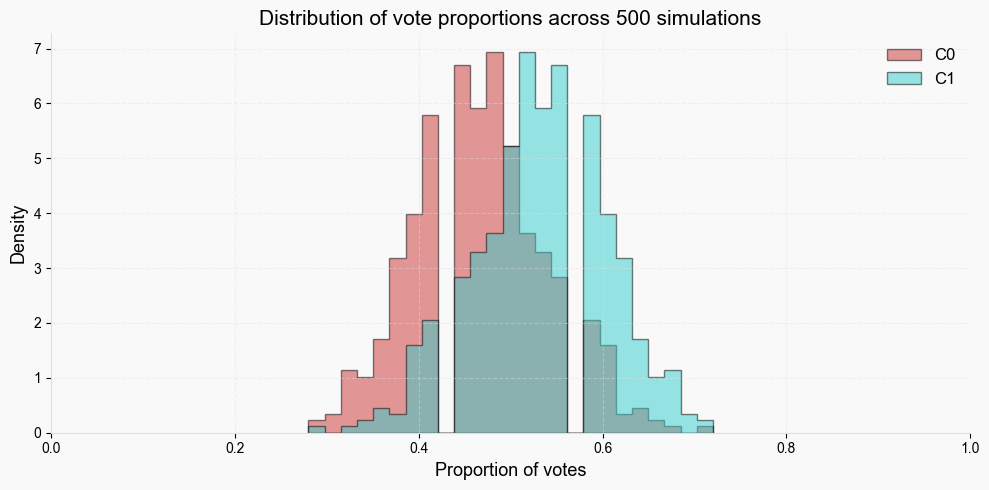

In [10]:
# Higher contrast colors for candidates
candidate_ids = df_simulations["candidate_id"].unique()
n_cand = len(candidate_ids)
colors = [colorsys.hls_to_rgb(i / n_cand, 0.5, 0.6) for i in range(n_cand)]  # darker colors

# Plot distributions
fig, ax = plt.subplots(figsize=(10, 5), facecolor="#f9f9f9")
ax.set_facecolor("#f9f9f9")

for i, cid in enumerate(candidate_ids):
    proportions = df_simulations.loc[df_simulations["candidate_id"] == cid, "proportion"]
    ax.hist(proportions, bins=25, density=True,
            alpha=0.5, color=colors[i], edgecolor="#000000",
            label=f"C{cid}", rwidth=1, histtype='stepfilled')  # rwidth=1 supprime l'écart

# Labels and title
ax.set_xlabel("Proportion of votes", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title(f"Distribution of vote proportions across {df_simulations['simulation_number'].nunique()} simulations",
             fontsize=15)
ax.legend(frameon=False, fontsize=12)

# Grid, spines, and limits
ax.set_xlim(0, 1)
ax.grid(True, linestyle='--', alpha=0.4, color='#e0e0e0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_edgecolor('#e0e0e0')
    ax.spines[spine].set_linewidth(0.8)

plt.tight_layout()
plt.show()
